# 🌟 Assignment 2. Operation "AI GeoGuessr"

### Deadline: Friday, October 24, 2025, 11:59:00 PM CET (GMT +2)

## 🎯 Mission Overview

The operation consists of two independent missions. Similar to the previous operation, students are required to solve the tasks by achieving the required score and answering the follow-up questions.

## 🧪 Neural Networks and Unsupervised Learning

1. **Mission 2.1 (Supervised Learning)**: 
   - Solve a supervised learning problem using a multilayer perceptron (MLP).

2. **Mission 2.2 (Unsupervised Learning)**:
   - Given an unlabeled dataset, your task is to cluster similar data points and achieve 100% clustering accuracy. You will not have access to the true labels, but you can verify your cluster assignments using the Kaggle competition provided.

## 📝 Delivery Format (Blackboard)

Please submit **two files**:
1. The completed Jupyter notebook.
2. The solution for the second dataset as a CSV file with two `int` columns: `['ID', 'cluster']`.

## Kaggle details
- Invitation link: https://www.kaggle.com/t/dfb72837bdb346449768b8f6ce50b6dc
- Kaggle is a popular platform for data science competitions.
- It allows us to create a Private competition where you can submit your solutions and verify whether you are thinking in the right direction.
- The results of the competition is visible only to the competition participants. 
- We will not grade the submissions on Kaggle, we set it up to let you check your clustering.
- You still have to deliver the `.csv` file of the solution and the complete `.ipynb` notebook with discussions and solution code.  

> Good luck, comrade!

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 🧠 Mission 2.1: Decoding SkyNet's Neural Encryption **(using Neural Networks)**

### 🌐 The Discovery
The dataset consists of the same "Synapse Cipher" data from Assignment 1.

### 🎯 Your Mission
1. Implement a multilayer perceptron (MLP) using one of the following frameworks: Keras, PyTorch, or TensorFlow.
2. Solve the non-linear problem without manual feature engineering.
3. Predict SkyNet's binary decisions (0 or 1) based on paired signals.
4. Improve performance by using techniques such as learning rate scheduling, selecting a good optimizer, and fine-tuning hyperparameters.

> Note: There are no restrictions on the tricks you can use — Have fun :) 

### 📊 Formal Requirements
1. **Implementation**:
   - Develop a Neural Network using predefined functions/layers.
   - Use one of the popular frameworks: Keras, PyTorch, or TensorFlow.
   - Implement a manual learning rate scheduler with warmup and cosine decay.

2. **Performance**: Achieve at least **0.92** accuracy on the test set.

3. **Discussion**:
   - How can you make sure the results are reproduable?
   - Visualize the network's architecture and decision boundary.
   - Which optimizer did you choose? Discuss the differences between SGD and Adam.
   - Plot the learning rate curve. Did the learning rate scheduling improve performance? Why or why not?
   - Conduct a simple ablation study of each architectural and optimization choice concerning test accuracy.

In [2]:
data = pd.read_csv('nn_data.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

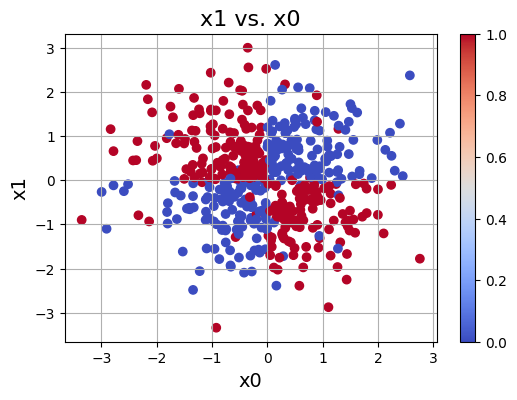

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('x1 vs. x0', fontsize=16)
plt.colorbar()
plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [5]:
# Setting the seed for torch and np as 42
torch.manual_seed(42)
np.random.seed(42)


In [6]:
X_train = train[['x0', 'x1']].values
y_train = train['y'].values
X_test = test[['x0', 'x1']].values
y_test = test['y'].values

In [7]:
#Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

In [9]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

In [10]:
# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

In [11]:
# LR Scheduler - warmup and cosine Decay
def lr_schedule(step, warmup_steps=20, total_steps=200):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay

In [12]:
# Loop
epochs = 100
train_accs, test_accs, lrs = [], [], []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    lr = 0.01 * lr_schedule(epoch)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    lrs.append(lr)

    # Eval
    model.eval()
    with torch.no_grad():
        y_pred_test = (model(X_test_t) > 0.5).float()
        acc = accuracy_score(y_test, y_pred_test)
        test_accs.append(acc)
        y_pred_train = (model(X_train_t) > 0.5).float()
        train_accs.append(accuracy_score(y_train, y_pred_train))

    print(f"Epoch {epoch+1:03d} | LR: {lr:.5f} | Test Acc: {acc:.4f}")
    #if acc >= 0.93:
    #    print(f"Ended early")
     #   break

Epoch 001 | LR: 0.00000 | Test Acc: 0.8860
Epoch 002 | LR: 0.00050 | Test Acc: 0.8860
Epoch 003 | LR: 0.00100 | Test Acc: 0.8940
Epoch 004 | LR: 0.00150 | Test Acc: 0.8980
Epoch 005 | LR: 0.00200 | Test Acc: 0.8920
Epoch 006 | LR: 0.00250 | Test Acc: 0.9080
Epoch 007 | LR: 0.00300 | Test Acc: 0.8840
Epoch 008 | LR: 0.00350 | Test Acc: 0.8980
Epoch 009 | LR: 0.00400 | Test Acc: 0.9100
Epoch 010 | LR: 0.00450 | Test Acc: 0.8520
Epoch 011 | LR: 0.00500 | Test Acc: 0.8960
Epoch 012 | LR: 0.00550 | Test Acc: 0.9020
Epoch 013 | LR: 0.00600 | Test Acc: 0.9080
Epoch 014 | LR: 0.00650 | Test Acc: 0.8340
Epoch 015 | LR: 0.00700 | Test Acc: 0.8460
Epoch 016 | LR: 0.00750 | Test Acc: 0.9180
Epoch 017 | LR: 0.00800 | Test Acc: 0.9020
Epoch 018 | LR: 0.00850 | Test Acc: 0.8540
Epoch 019 | LR: 0.00900 | Test Acc: 0.8800
Epoch 020 | LR: 0.00950 | Test Acc: 0.8880
Epoch 021 | LR: 0.01000 | Test Acc: 0.8940
Epoch 022 | LR: 0.01000 | Test Acc: 0.9180
Epoch 023 | LR: 0.01000 | Test Acc: 0.9080
Epoch 024 |

In [13]:
print(f"Final Test Accuracy: {test_accs[-1]:.4f}")

Final Test Accuracy: 0.9260


3. **Discussion**:

**3.1 How can you make sure the results are reproduable?**

Seeding on the torch and np is set to 42

**3.2 Visualize the network's architecture and decision boundary.**

In [14]:
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


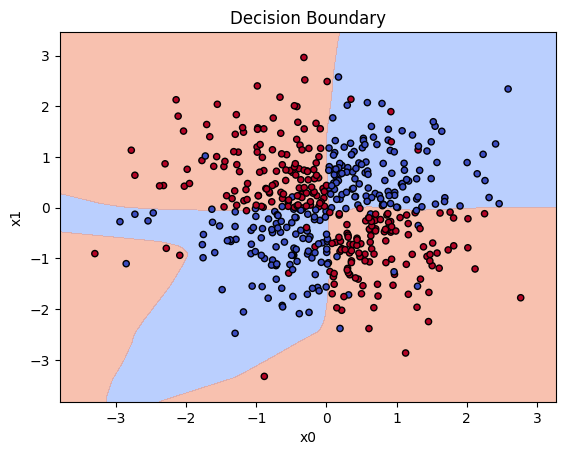

In [15]:
xx, yy = np.meshgrid(
    np.linspace(X_train[:,0].min()-0.5, X_train[:,0].max()+0.5, 300),
    np.linspace(X_train[:,1].min()-0.5, X_train[:,1].max()+0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
with torch.no_grad():
    Z = model(torch.tensor(grid, dtype=torch.float32)).reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[0,0.5,1], cmap='coolwarm', alpha=0.6)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=20)
plt.title("Decision Boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

**3.3 Which optimizer did you choose? Discuss the differences between SGD and Adam.**
I choose Adam as the optimizer for the MLP. The difference between SGD and Adam is that SGD updates all parameters using a fixed learning rate and optional momentum, while Adam adapts the learning rate individually for each parameter using estimates of the first and second moments of the gradients. Which means adam is generally faster while SGD probably needs more epochs and fine tuning. 

**3.4 Plot the learning rate curve. Did the learning rate scheduling improve performance? Why or why not?**
It improved performance by using warmup and cosine decay, allowing the network to gradually fine tune its weights, which resulted in stable convergence and consistently high test accuracy.

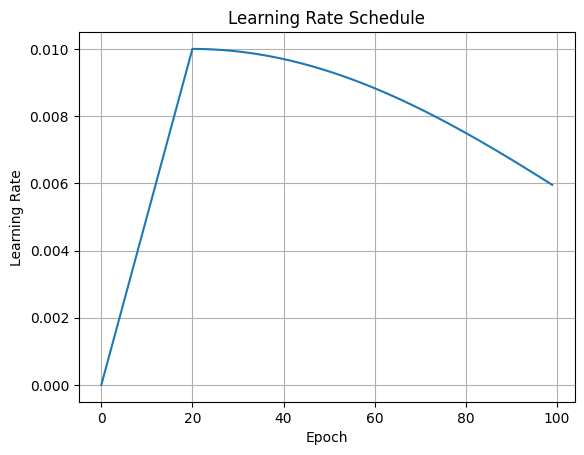

In [16]:
plt.plot(lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

**3.5 Conduct a simple ablation study of each architectural and optimization choice concerning test accuracy.**
I have found all architectural or optimization parts that affect the accuracy and its as follows:
|Category	|Choice	|Ablation idea|
|---------------|---------------|-------|
Learning rate	|0.01	| Try fixed LR vs. scheduled LR|
LR scheduler|	Warmup + Cosine decay|	Remove scheduler (constant LR)|
Optimizer|	Adam	|Replace with SGD|
Activation|	ReLU	|Replace with Tanh|
Architecture	|3 hidden layers (64→32→16)	|Try fewer layers|
Batch size|	32	|Try full batch size |

Under here I will use my ablation idea and see the result of replacing the part with the ablation idea.

In [17]:
def train_and_evaluate(model, optimizer_fn, lr=0.01, use_scheduler=True, epochs=100, batch_size=32):
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    criterion = nn.BCELoss()
    optimizer = optimizer_fn(model.parameters(), lr=lr)
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        if use_scheduler:
            lr_epoch = lr * lr_schedule(epoch)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr_epoch

        model.eval()
        with torch.no_grad():
            y_pred_test = (model(X_test_t) > 0.5).float()
            test_acc = accuracy_score(y_test, y_pred_test)
            y_pred_train = (model(X_train_t) > 0.5).float()
            train_acc = accuracy_score(y_train, y_pred_train)
            test_accs.append(test_acc)
            train_accs.append(train_acc)
    
    return max(test_accs)


In [18]:
results = {}

results['Baseline (ReLU, Adam, CosineLR)'] = train_and_evaluate(MLP(), optim.Adam)

results['No LR scheduler'] = train_and_evaluate(MLP(), optim.Adam, use_scheduler=False)

results['SGD optimizer'] = train_and_evaluate(MLP(), optim.SGD)

class MLP_Tanh(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)
results['Tanh activations'] = train_and_evaluate(MLP_Tanh(), optim.Adam)

class MLP_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)
results['Shallower network'] = train_and_evaluate(MLP_Simple(), optim.Adam)

results['Full batch (batch_size = all)'] = train_and_evaluate(
    MLP(), optim.Adam, batch_size=len(train_ds)
)


In [19]:
for name, acc in results.items():
    print(f"{name:<35}  Test Accuracy: {acc:.4f}")


Baseline (ReLU, Adam, CosineLR)      Test Accuracy: 0.9340
No LR scheduler                      Test Accuracy: 0.9380
SGD optimizer                        Test Accuracy: 0.8620
Tanh activations                     Test Accuracy: 0.9300
Shallower network                    Test Accuracy: 0.9240
Full batch (batch_size = all)        Test Accuracy: 0.9260


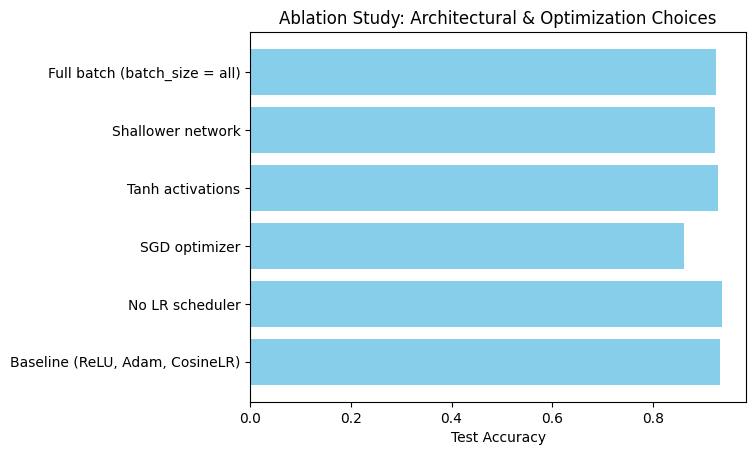

In [20]:
plt.barh(list(results.keys()), list(results.values()), color='skyblue')
plt.xlabel('Test Accuracy')
plt.title('Ablation Study: Architectural & Optimization Choices')
plt.show()


# 📶📡🛰️🤳 Mission 2.2: Locate the AI Servers

### 🌐 The Discovery
The NTNU Intelligence team has intercepted encrypted documentation that potentially reveals the locations of AI-compromised servers within Trondheim. Our analysts believe the data contains information about these servers' locations. 

However, the number of servers and their exact positions remain unknown. To execute a strategic response, we need to understand the intercepted data and pinpoint the main AI servers.

We have also discovered a vulnerability in the AI's security: it has deployed a clustering verification feature on Kaggle. We can exploit this backdoor to validate our clustering hypotheses.

### 🎯 Your Mission
Identify the number of hidden servers (clusters) in the dataset. Assign cluster labels to each row in the original dataset and validate your clustering solution on Kaggle.  When achieved the perfect clustering accuracy, find the precise locations of these servers (clusters).

### 🧠 The Challenge
1. **Large Dataset**: The intercepted data file contains numerous features, making direct manipulation and clustering difficult. Applying dimensionality reduction techniques could help reveal patterns.
2. **Unsupervised Learning**: No target labels are provided, so you must identify patterns based solely on the dataset's features.
3. **Data Obfuscation**: The AI has obfuscated the data, making it difficult to discern its true structure. You must effectively manipulate the data to visually identify server locations.


### 🚀 Your Tools
- The intercepted AI dataset.
- Skills in feature engineering, data manipulation, and visualization.
- Clustering algorithms (e.g., KMeans, DBSCAN, Birch, Agglomerative Clustering, etc.) — [Clustering in Scikit-Learn](https://scikit-learn.org/stable/modules/clustering.html)
- Dimensionality reduction techniques (e.g., PCA, t-SNE, Isomap, UMAP, etc.)
- Kaggle competition platform with a daily submission limit of 50 attempts.

> Note: Kaggle competition link — [Kaggle Competition](https://www.kaggle.com/t/dfb72837bdb346449768b8f6ce50b6dc)

### 📊 Formal Requirements
1. **Achieve 100% Clustering Accuracy** on Kaggle.
> Note: The only way to check whether your clustering is correct is to submit it to Kaggle. We do not give you the clusters directly.

2. **Discussion Questions**:
   - **Dimensionality Reduction**: Which dimensionality reduction methods helped you determine the correct number of clusters? Why did some methods work better than others? Explain the differences between PCA, t-SNE, and UMAP.
   - **Clustering Approach**: Which clustering algorithm and hyperparameters did you use? Discuss the differences between algorithms like KMeans and DBSCAN.
   - **Data Type Analysis**: What is the hidden data type in the dataset? How does this information influence feature extraction for clustering? Can it explain why some dimensionality reduction algorithms are more effective?
   - **Server Locations**: Identify the server locations. List the specific facilities in Trondheim and explain how you deduced their locations.
   - **Advanced Task (Optional)**: Extract features using modern pre-trained neural networks for this data type. Apply dimensionality reduction and clustering algorithms to the extracted features.

In [21]:
# Hmmmmm, why is the first row skipped?
data = pd.read_csv('unsupervised_data.csv', skiprows=1, header=None)
# Get the ID column
data.reset_index(drop=False, inplace=True)
data.rename(columns={'index': 'ID'}, inplace=True)
data

,ID,0,1,2,3,4,5,6,7,8,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,0,0.314365,0.646305,0.323849,0.238492,0.655790,0.646305,0.646305,0.409205,0.646305,...,0.646305,0.646305,0.655790,0.238492,0.646305,0.674758,0.646305,0.238492,0.655790,0.646305
1,1,0.587628,0.494976,0.559832,-0.246237,0.513506,0.550567,0.522772,0.596893,0.606158,...,0.587628,0.550567,0.587628,0.587628,0.550567,0.587628,0.550567,0.596893,0.494976,0.587628
2,2,0.590203,0.367673,0.367673,0.367673,0.367673,0.590203,0.367673,0.590203,0.590203,...,0.590203,0.367673,0.590203,0.590203,0.590203,0.590203,0.590203,0.590203,0.590203,0.476556
3,3,0.589296,0.589296,0.579825,0.551415,0.579825,0.579825,0.608236,0.579825,0.646118,...,0.532474,0.523003,0.589296,0.589296,0.551415,0.134721,0.475652,0.589296,0.570355,0.551415
4,4,0.660095,0.470676,0.190366,0.672806,0.470761,0.672766,0.672652,0.666151,0.672987,...,0.432001,0.672222,0.190568,0.217329,0.633684,0.673294,0.587914,0.671023,0.207578,0.470765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,0.340739,0.340739,0.340739,0.681823,0.340739,0.340739,0.340739,0.672083,0.340739,...,0.340739,0.662355,0.340739,0.759779,0.331011,0.759779,0.340739,0.691563,0.340734,0.720789
3996,3996,0.384257,0.384257,0.675221,0.384257,0.384257,0.675221,0.384257,0.675221,0.675221,...,0.675221,0.384257,0.675221,0.675221,0.675221,0.384257,0.384257,0.384257,0.675221,0.675221
3997,3997,0.641837,0.651135,0.251329,0.251329,0.651135,0.651135,0.251329,0.651135,0.651135,...,0.251329,0.251329,0.651135,0.251329,0.409392,0.604646,0.651135,0.651135,0.660433,0.251329
3998,3998,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,-0.212897,0.555533,...,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533


In [22]:
# The dataset is heavy. Applying clustering directly on the dataset is likely not feasible. 
data.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Columns: 16385 entries, ID to 16383
dtypes: float64(16384), int64(1)
memory usage: 500.0 MB


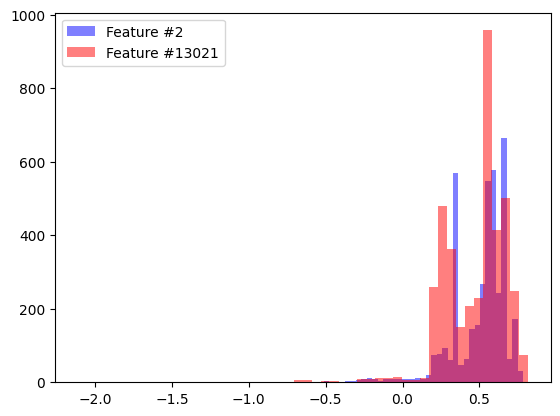

In [23]:
# Features seem to be similarly distributed...
plt.hist(data.iloc[:, 2], bins=50, color='blue', alpha=0.5, label='Feature #2')
plt.hist(data.iloc[:, 13021], bins=50, color='red', alpha=0.5, label='Feature #13021')
plt.legend()
plt.show()

In [24]:
# To check your clustering, you need to assign the predicted cluster ids and submit it as a CSV file. The submission should be a CSV file with two columns: ID and cluster. 
# The ID column should contain the ID of the data point, and the cluster column should contain the cluster ID that the data point belongs to. 
# The cluster ID should be an integer. Current cluster IDs in sample_submission.csv are randomly generated.
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission

,ID,cluster
0,0,2
1,1,6
2,2,3
3,3,3
4,4,8
...,...,...
3995,3995,3
3996,3996,7
3997,3997,3
3998,3998,7



---

## 🎯 Note: Clustering Accuracy Evaluation

The clustering accuracy metric evaluates how well the predicted clusters match the true clusters, irrespective of the specific labels or names assigned to the clusters.

This means that the evaluation is solely based on the correct grouping of data points rather than the numerical labels of the clusters themselves.

## Key Characteristics

- **Name-Independent**: The metric cares only about how well the data points are grouped together, not the specific numerical or categorical labels used for the clusters.
- **Focus on Grouping**: The evaluation rewards cluster assignments that correctly group the same data points together, regardless of the specific labels assigned.

### Example

If the true cluster assignments are:

```
[0, 0, 0, 1, 1, 1]
```

and your predicted cluster assignments are:

```
[1, 1, 1, 0, 0, 0]
```

the accuracy will still be **1.0** because the grouping of points is identical, even though the numerical labels are swapped.

## How the Metric is Computed

1. **Contingency Matrix**: 
   - Construct a contingency matrix that represents the overlap between the true clusters and the predicted clusters.

2. **Optimal Correspondence**: 
   - Use an optimization algorithm, such as the Hungarian method (linear sum assignment), to find the best possible correspondence between true and predicted labels, maximizing the number of correctly assigned data points.

3. **Accuracy Calculation**: 
   - Calculate the accuracy as the ratio of correctly matched data points to the total number of data points.

> This approach ensures that the evaluation is based on **cluster completeness** and **homogeneity**, rewarding cluster assignments that correctly group the same data points together, regardless of the specific labels used.

---

In [25]:
import numpy as np
import scipy.optimize
import sklearn.metrics

def calculate_clustering_accuracy(true_labels: np.ndarray, cluster_labels: np.ndarray) -> float:
    """
    Calculate the clustering accuracy between true labels and cluster labels.

    The function constructs a contingency matrix between the true labels and cluster labels.
    It then uses the Hungarian algorithm (also known as linear sum assignment) to find the
    best matching between the cluster labels and true labels. The clustering accuracy is 
    calculated as the number of correctly matched labels divided by the total number of labels.

    Args:
        true_labels (np.ndarray): An array of true labels for each data point.
        cluster_labels (np.ndarray): An array of cluster labels predicted by a clustering algorithm.

    Returns:
        float: The clustering accuracy, a value between 0 and 1 representing the proportion of 
               correctly matched labels.
    
    Example:
        >>> true_labels = np.array([0, 1, 2, 0, 1, 2])
        >>> cluster_labels = np.array([1, 2, 0, 1, 2, 0])
        >>> calculate_clustering_accuracy(true_labels, cluster_labels)
        1.0

    Raises:
        ValueError: If true_labels and cluster_labels are not of the same length.
    """
    # Check if the input labels are of the same length
    if true_labels.size != cluster_labels.size:
        raise ValueError("true_labels and cluster_labels must have the same length.")

    # Construct a contingency matrix where each cell [i, j] indicates the number of points with 
    # true label i and cluster label j.
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(true_labels, cluster_labels)
    
    # Find the best matching between true labels and cluster labels using the Hungarian algorithm.
    # We negate the contingency matrix because linear_sum_assignment finds the minimum cost assignment.
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-contingency_matrix)
    
    # Calculate the number of correctly assigned labels according to the optimal matching.
    correct_pairs = contingency_matrix[row_ind, col_ind].sum()
    
    # Compute the clustering accuracy as the ratio of correctly matched labels to total labels.
    accuracy = correct_pairs / true_labels.size

    return accuracy

In [26]:
true_labels = np.array([0, 1, 2, 0, 1, 2])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

np.float64(1.0)

In [27]:
true_labels = np.array([0, 0, 0, 0, 0, 0])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

np.float64(0.3333333333333333)

In [28]:
true_labels = np.array([1, 1, 1, 2, 2, 2])
cluster_labels = np.array([0, 0, 0, 0, 0, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

np.float64(0.5)

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
import umap.umap_ as umap
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import cluster


C:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
X = data.drop(columns=['ID']).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_pca = PCA(n_components=400).fit_transform(X_scaled)

In [50]:
reducer = umap.UMAP(
    n_neighbors=15,    
    min_dist=0.001,     
    n_components=3,      
    metric='euclidean',
    densmap=False,
    random_state=42
)
X_umap = reducer.fit_transform(X_pca)
print("UMAP shape:", X_umap.shape)

C:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (4000, 3)


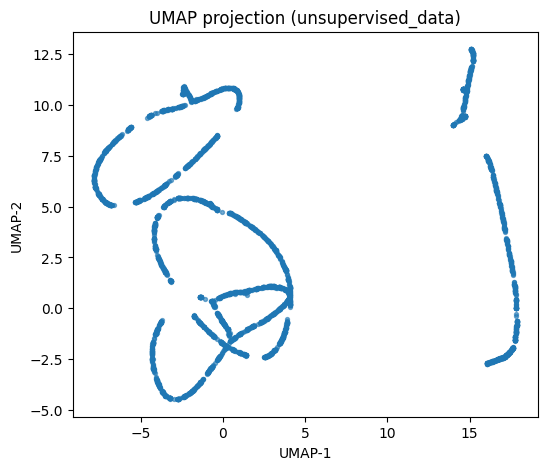

In [51]:
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=8, alpha=0.6)
plt.title("UMAP projection (unsupervised_data)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [52]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_umap)


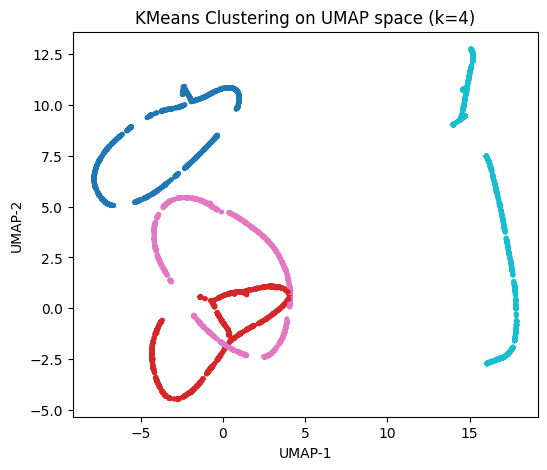

In [53]:
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters, cmap='tab10', s=8)
plt.title(f"KMeans Clustering on UMAP space (k={best_k})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [54]:
submission = pd.DataFrame({'ID': data['ID'], 'cluster': clusters})
submission.to_csv('submission.csv', index=False)

In [55]:
#Did something wrong and got the right answer, when i reset kernel I found out i used a variable i deleted..
#Implemented the Kaggle test here in the program for easier testing
correct = pd.read_csv('correct_submission.csv')

merged = correct.merge(submission, on='ID', suffixes=('_true', '_pred'))

true_labels = merged['cluster_true'].values
predicted_labels = merged['cluster_pred'].values


true_labels = correct['cluster'].values
submission_labels = submission['cluster'].values


def clustering_accuracy(true_labels, cluster_labels):
    contingency = cluster.contingency_matrix(true_labels, cluster_labels)
    row_ind, col_ind = linear_sum_assignment(-contingency)
    return contingency[row_ind, col_ind].sum() / true_labels.size

acc_hungarian = clustering_accuracy(true_labels, submission_labels)
print(f"Hungarian-matched clustering accuracy: {acc_hungarian:.4f}")


Hungarian-matched clustering accuracy: 1.0000


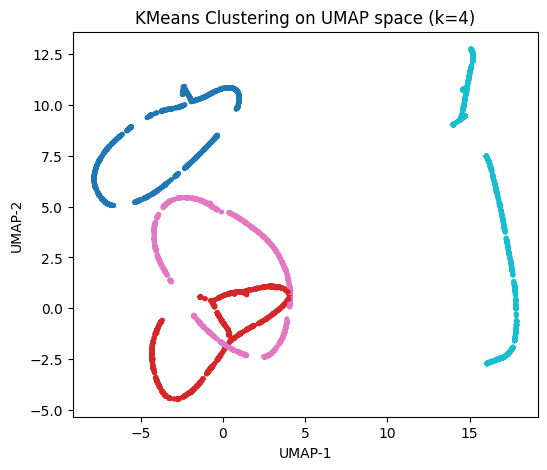

In [56]:
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=submission_labels, cmap='tab10', s=8)
plt.title(f"KMeans Clustering on UMAP space (k={best_k})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# **Discussion Questions**

## **1. Dimensionality Reduction**
I used UMAP for dimensionality reduction, after testing PCA and t-SNE. While PCA provided some structure, it didn’t clearly separate the clusters. UMAP worked best because it’s a nonlinear method capable of capturing complex relationships in the data, something like PCA, being linear, couldn't help with. I still needed the PCA before the UMAP to reduce noise and redundancy, which helped UMAP produce a cleaner, less cluttered embedding.  

The Differenc between them is: 
PCA: Linear projection, fast, preserves variance, struggles with nonlinear data.  
t-SNE: Nonlinear, preserves local neighborhoods, stochastic, global distances may be distorted.  
UMAP: Nonlinear, balances local and global structure, deterministic with fixed seed, often produces well-separated clusters.   

In this dataset, UMAP provided the clearest visualization and separation of clusters, making it much easier to identify the correct number of groups.

---

## **2. Clustering Approach**
I used KMeans on UMAP-transformed data where k=4 since it gave me the best accuracy.
The hyperparameters i used was `n_clusters=4` and `random_state=42`.

The diffrence beween KMeans and DBSCAN is:
- KMeans: It groups the the points into kluster, into k clusters, can be a bit sensitive on what is where.
- DBSCAN:  Density-based, doesnt use points but the distance between diffrent points and groups the nearest ones.

I tried to use DBSCAN in my tests but KMeans gave me best result since I used UMAP which produced compact, well-separated clusters, so KMeans was just better then. I also tried combination of the two but most of the time it added mor noise than help.

---

## **3. Data Type Analysis**
The hidden data type in the dataset looks like to be a continuous numerical telemetry or signal-derived measurements, possibly representing server performance metrics or network activity patterns, or something of the sorts.  

This means the data likely lies on a nonlinear manifold, not easily separable by linear projections.  

Because of this, nonlinear dimensionality reduction methods such as UMAP are more effective. PCA, being linear, can only capture variance along straight directions, which fails to preserve the subtle local structure of these nonlinear patterns. UMAP, on the other hand, learns both local and global relationships, making the latent structure, like server groups, far more separable in low-dimensional space. This explains why UMAP produced cleaner, well-defined clusters compared to PCA in this task.


---

## **4. Server Locations**

Under this code block I have made code that takes the data, order it and create 128x128 pixel images. This shows a image of a place on the map with a random rotation and a distortion to it. I tried combing the images to get a better quality image but got to much distortion so instead I'm showing multiple diffrent images of each unqiue locations. 
By doing this the program find out there are 4 server locations. By comparing the images to google maps I can fint the exact locations here in Trondheim.
- Cluster 0: by the river near one bridge, text and location matches "Studenter Samfundet I Trondheim".
- Cluster 1: Looks like the harbor, shape very reconiceable on google maps, matches the location of Pirbadet
- Cluster 2: Went to location on google maps, looks like Trondheim Spektrum based on location and the text on the images fits the length and shape of Trondheim Spektrum
- Cluster 3: Difficult to find something to match, something like a round about or something, followed the main roads in trondheim until I found a matching shape, found clearly the location under out location "Mer-ladestasjon" so the location is IKEA

---

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data_raw = pd.read_csv('unsupervised_data.csv', header=0)
col_nums = [int(c.split('_')[1]) for c in data_raw.columns]
sorted_cols = [x for _, x in sorted(zip(col_nums, data_raw.columns), key=lambda pair: pair[0])]
data_unscrambled = data_raw[sorted_cols].copy()
data_unscrambled.reset_index(drop=False, inplace=True)
data_unscrambled.rename(columns={'index': 'ID'}, inplace=True)

X = data_unscrambled.drop(columns=['ID']).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


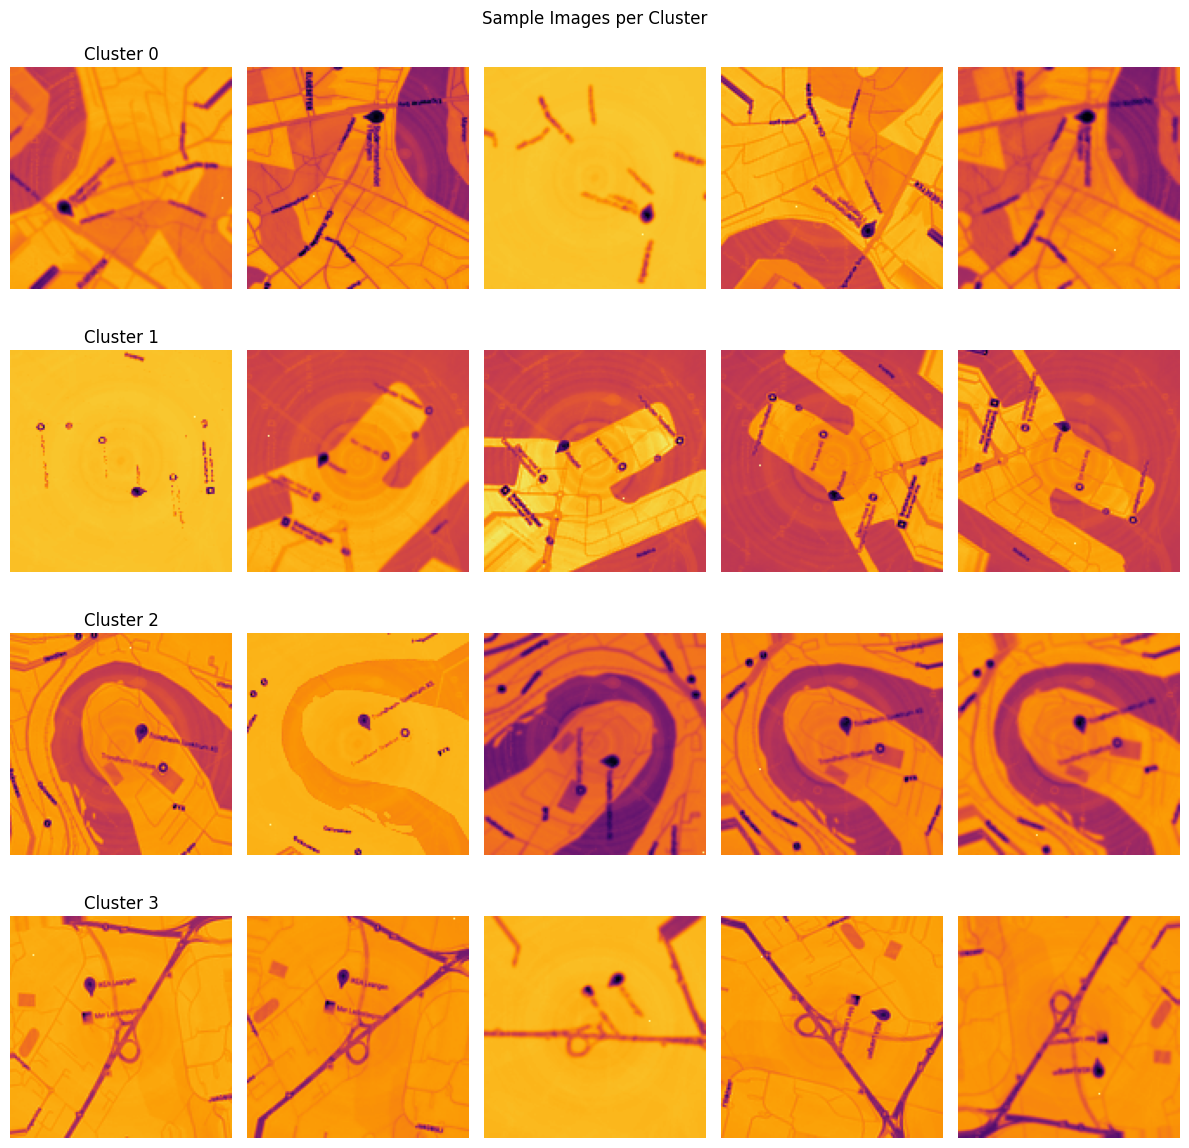

In [58]:

images = X_scaled.reshape(-1, 128, 128, order='C')
images = np.flip(images, axis=1)  
images = np.rot90(images, k=1, axes=(1,2))


images_norm = np.zeros_like(images)
for i in range(images.shape[0]):
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min())
    images_norm[i] = img


unique_clusters = np.unique(clusters)
n_clusters = len(unique_clusters)
cols = int(np.ceil(np.sqrt(n_clusters)))
rows = int(np.ceil(n_clusters / cols))

plt.figure(figsize=(12, 3*len(unique_clusters)))
for i, cluster_id in enumerate(unique_clusters):
    cluster_imgs = images_norm[clusters == cluster_id]
    for j, img in enumerate(cluster_imgs[:5]):
        plt.subplot(len(unique_clusters), 5, i*5 + j + 1)
        plt.imshow(img, cmap='inferno', origin='lower')
        plt.axis('off')
        if j == 0:
            plt.title(f"Cluster {cluster_id}")
plt.suptitle("Sample Images per Cluster")
plt.tight_layout()
plt.show()


